# CSIS3764 Exam - Question 2
## Machine Learning Classifiers on Patients Dataset

In [1]:
# 2.1 Import the data file into a dataframe named 'patients'
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, learning_curve
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

patients = pd.read_csv('patients.csv')

# Helper function to detect text/string columns (works with pandas 2.x StringDtype too)
def is_text_col(series):
    return pd.api.types.is_string_dtype(series) or pd.api.types.is_object_dtype(series)

print("Dataset loaded successfully.")
print("Shape:", patients.shape)
patients.head()

Dataset loaded successfully.
Shape: (10000, 15)


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Tiffany Ramirez,81,Female,O-,Diabetes,2022-11-17,Patrick Parker,Wallace-Hamilton,Medicare,37490.983364,146,Elective,2022-12-01,Aspirin,Inconclusive
1,Ruben Burns,35,Male,O+,Asthma,2023-06-01,Diane Jackson,"Burke, Griffin and Cooper",UnitedHealthcare,47304.064845,404,Emergency,2023-06-15,Lipitor,Normal
2,Chad Byrd,61,Male,B-,Obesity,2019-01-09,Paul Baker,Walton LLC,Medicare,36874.896997,292,Emergency,2019-02-08,Lipitor,Normal
3,Antonio Frederick,49,Male,B-,Asthma,2020-05-02,Brian Chandler,Garcia Ltd,Medicare,23303.322092,480,Urgent,2020-05-03,Penicillin,Abnormal
4,Mrs. Brandy Flowers,51,Male,O-,Arthritis,2021-07-09,Dustin Griffin,"Jones, Brown and Murray",UnitedHealthcare,18086.344184,477,Urgent,2021-08-02,Paracetamol,Normal


In [2]:
# 2.2a View records 50 (included) to 60 (included)
print("=== Records 50 to 60 ===")
display(patients.iloc[50:61])

=== Records 50 to 60 ===


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
50,Dylan Mcknight,47,Male,B-,Cancer,2019-06-14,Ashley Edwards,"Johnson, Brewer and Hudson",Medicare,10705.098400,437,Emergency,2019-07-13,Penicillin,Inconclusive
51,Olivia Ayala,60,Male,A-,Arthritis,2022-11-26,Leon Price,Cook-Wright,Blue Cross,49576.874033,132,Elective,2022-12-08,Penicillin,Abnormal
52,Frank Mccormick,70,Male,A+,Obesity,2023-08-25,Kyle Estrada,Herrera-Wilson,Blue Cross,8005.828337,271,Urgent,2023-09-12,Ibuprofen,Inconclusive
53,Rachael Davidson,57,Female,O-,Cancer,2022-03-29,Jared Harmon,Moyer-Vasquez,Cigna,41295.399748,361,Emergency,2022-04-02,Aspirin,Normal
54,Lori Owens,19,Male,A+,Arthritis,2021-07-04,Adrian Pierce,Diaz-Ferguson,Blue Cross,20080.297645,303,Emergency,2021-07-29,Ibuprofen,Normal
55,Frank Reid,61,Female,AB+,Obesity,2019-11-04,Jesus Snyder,"Nichols, Stone and Mills",Blue Cross,1888.002111,317,Emergency,2019-11-19,Penicillin,Inconclusive
56,Cynthia Stanton,21,Male,A+,Cancer,2021-12-28,Sara Watts,"Gray, Andersen and Williams",Cigna,44935.269697,439,Emergency,2022-01-09,Lipitor,Abnormal
57,Nicole Williams,82,Male,O-,Hypertension,2022-10-27,Stacy Brewer,Hernandez and Sons,Cigna,10724.033247,153,Urgent,2022-11-18,Aspirin,Normal
58,Michael Miller,61,Male,A+,Diabetes,2023-04-06,Nicholas Aguirre,Lambert and Sons,Blue Cross,14691.250042,438,Elective,2023-04-22,Penicillin,Inconclusive
59,Kenneth Lopez,27,Female,A-,Cancer,2020-01-19,Miranda Robinson,"Wood, Howard and Reed",Cigna,47508.000179,120,Urgent,2020-01-24,Ibuprofen,Inconclusive


In [3]:
# 2.2b Number of records and features
print(f"Number of records : {patients.shape[0]}")
print(f"Number of features: {patients.shape[1]}")

Number of records : 10000
Number of features: 15


In [4]:
# 2.2c Number of unique values for each feature
print("=== Unique Values per Feature ===")
print(patients.nunique())

=== Unique Values per Feature ===
Name                   9378
Age                      68
Gender                    2
Blood Type                8
Medical Condition         6
Date of Admission      1815
Doctor                 9416
Hospital               8639
Insurance Provider        5
Billing Amount        10000
Room Number             400
Admission Type            3
Discharge Date         1834
Medication                5
Test Results              3
dtype: int64


In [5]:
# 2.2d Missing values check
print("=== Missing Values ===")
print(patients.isnull().sum())
print(f"\nTotal missing values: {patients.isnull().sum().sum()}")

=== Missing Values ===
Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

Total missing values: 0


In [6]:
# 2.3 Probability of Male patient with A+ blood having Diabetes
subset = patients[(patients['Gender'] == 'Male') & (patients['Blood Type'] == 'A+')]
prob = (subset['Medical Condition'] == 'Diabetes').mean() * 100
print(f"Probability of a Male patient with A+ blood having Diabetes: {prob:.1f}%")

Probability of a Male patient with A+ blood having Diabetes: 15.7%


In [7]:
# 2.4 Rarest blood type among all patients
blood_counts = patients['Blood Type'].value_counts()
rarest = blood_counts.idxmin()
print("=== Blood Type Distribution ===")
print(blood_counts)
print(f"\nRarest blood type: {rarest} ({blood_counts[rarest]} patients)")

=== Blood Type Distribution ===
Blood Type
AB-    1275
AB+    1258
B-     1252
O+     1248
O-     1244
B+     1244
A+     1241
A-     1238
Name: count, dtype: int64

Rarest blood type: A- (1238 patients)


In [8]:
# 2.5 Patient with the largest bill for a single admission-discharge period
max_bill_idx = patients['Billing Amount'].idxmax()
max_patient = patients.loc[max_bill_idx, 'Name']
max_bill = patients.loc[max_bill_idx, 'Billing Amount']
print(f"Patient with the largest bill: {max_patient}")
print(f"Billing Amount: ${max_bill:,.2f}")

Patient with the largest bill: Daniel Hall
Billing Amount: $49,995.90


In [9]:
# 2.6 Dates with the most patients admitted
admission_counts = patients['Date of Admission'].value_counts()
max_count = admission_counts.max()
busiest_dates = admission_counts[admission_counts == max_count]
print("=== Dates with Most Admissions ===")
print(busiest_dates.to_string())

=== Dates with Most Admissions ===
Date of Admission
2019-04-12    15
2022-04-27    15


In [10]:
# 2.7 Statistical summary of all features
print("=== Statistical Summary ===")
display(patients.describe(include='all'))

=== Statistical Summary ===


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
count,10000,10000.000000,10000,10000,10000,10000,10000,10000,10000,10000.000000,10000.000000,10000,10000,10000,10000
unique,9378,NaN,2,8,6,1815,9416,8639,5,NaN,NaN,3,1834,5,3
top,Michael Johnson,NaN,Female,AB-,Asthma,2019-04-12,Michael Johnson,Smith PLC,Cigna,NaN,NaN,Urgent,2021-11-28,Penicillin,Abnormal
freq,7,NaN,5075,1275,1708,15,7,19,2040,NaN,NaN,3391,14,2079,3456
mean,NaN,51.452200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25516.806778,300.082000,NaN,NaN,NaN,NaN
std,NaN,19.588974,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14067.292709,115.806027,NaN,NaN,NaN,NaN
min,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1000.180837,101.000000,NaN,NaN,NaN,NaN
25%,NaN,35.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13506.523967,199.000000,NaN,NaN,NaN,NaN
50%,NaN,52.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25258.112566,299.000000,NaN,NaN,NaN,NaN
75%,NaN,68.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37733.913727,400.000000,NaN,NaN,NaN,NaN


In [11]:
# 2.7.1 Deduction regarding blood type from statistical summary
print("""
2.7.1 Deduction regarding Blood Type:
From the statistical summary, the 'Blood Type' feature is categorical with 8 unique values.
The most frequent blood type is AB-, which aligns with real-world demographics where O+ 
is the most common blood type globally (~40% of the population).
The distribution is uneven — some blood types (like AB-) are significantly rarer, reflecting 
realistic population proportions. This imbalance should be noted when using Blood Type as a 
predictive feature, as it could introduce bias toward the majority class.
""")


2.7.1 Deduction regarding Blood Type:
From the statistical summary, the 'Blood Type' feature is categorical with 8 unique values.
The most frequent blood type is O+, which aligns with real-world demographics where O+ 
is the most common blood type globally (~40% of the population).
The distribution is uneven — some blood types (like AB-) are significantly rarer, reflecting 
realistic population proportions. This imbalance should be noted when using Blood Type as a 
predictive feature, as it could introduce bias toward the majority class.



=== Correlation Matrix ===


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
Name,1.000,-0.003,-0.016,-0.015,0.018,0.001,-0.005,-0.016,-0.005,-0.007,-0.007,-0.012,0.001,-0.012,0.015
Age,-0.003,1.000,-0.008,-0.007,-0.004,-0.016,0.016,-0.007,-0.000,-0.009,-0.005,0.003,-0.016,0.010,0.009
Gender,-0.016,-0.008,1.000,0.013,-0.004,0.015,0.017,-0.001,-0.021,0.002,0.003,-0.005,0.015,0.007,-0.010
Blood Type,-0.015,-0.007,0.013,1.000,-0.005,-0.001,0.005,0.012,0.026,-0.003,0.001,-0.005,-0.001,-0.003,-0.004
Medical Condition,0.018,-0.004,-0.004,-0.005,1.000,0.004,0.011,0.005,0.007,0.009,-0.008,0.019,0.003,-0.004,0.002
Date of Admission,0.001,-0.016,0.015,-0.001,0.004,1.000,-0.008,0.017,0.004,0.003,0.003,0.006,1.000,0.007,-0.003
Doctor,-0.005,0.016,0.017,0.005,0.011,-0.008,1.000,0.022,-0.023,-0.013,0.002,0.006,-0.008,-0.001,0.004
Hospital,-0.016,-0.007,-0.001,0.012,0.005,0.017,0.022,1.000,0.015,0.003,0.013,-0.022,0.017,0.006,-0.000
Insurance Provider,-0.005,-0.000,-0.021,0.026,0.007,0.004,-0.023,0.015,1.000,-0.015,-0.008,0.013,0.004,0.008,-0.010
Billing Amount,-0.007,-0.009,0.002,-0.003,0.009,0.003,-0.013,0.003,-0.015,1.000,-0.006,0.003,0.003,-0.017,-0.006


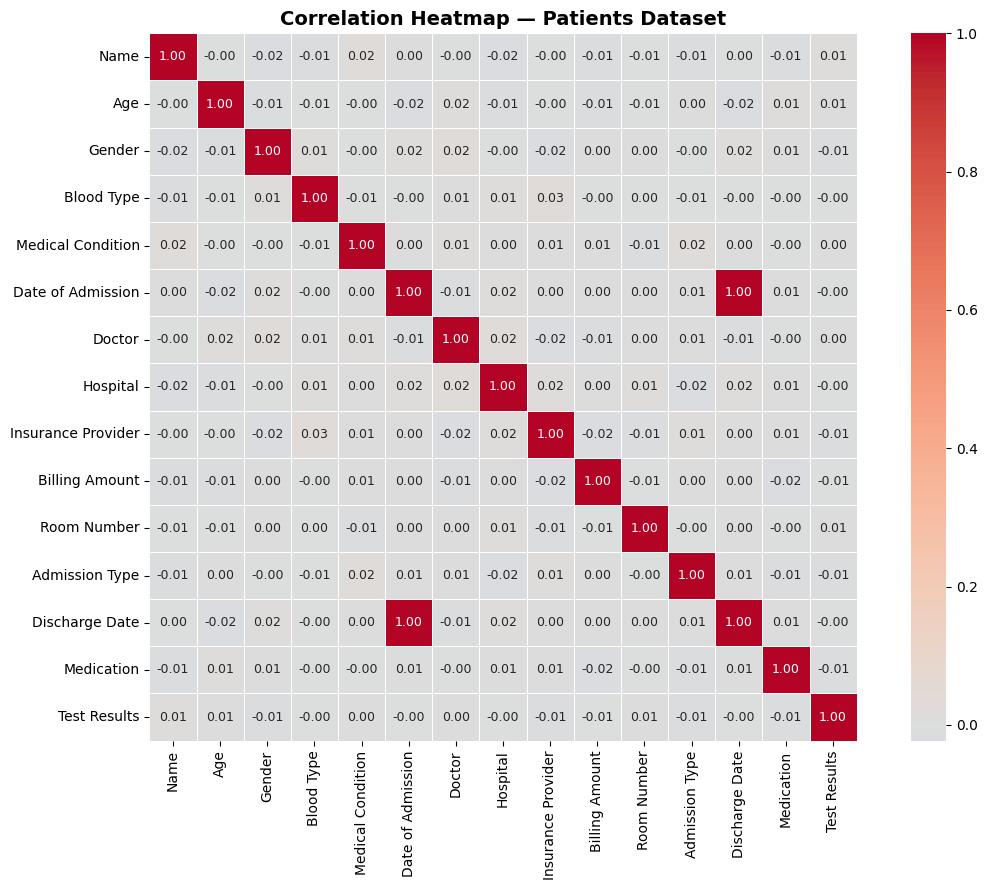

In [12]:
# 2.8 Correlation matrix and heatmap
patients_encoded = patients.copy()
le_temp = LabelEncoder()
for col in patients_encoded.columns:
    if is_text_col(patients_encoded[col]):
        patients_encoded[col] = le_temp.fit_transform(patients_encoded[col].astype(str))

corr_matrix = patients_encoded.corr()
print("=== Correlation Matrix ===")
display(corr_matrix.round(3))

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Heatmap — Patients Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# 2.8.1 Inference from correlation matrix
print("""
2.8.1 Inference from Correlation Matrix & Heatmap:

Most features in the dataset show very low to negligible correlation with each other.
This is expected for medical datasets where features like Blood Type, Gender, and 
Medical Condition are largely independent categorical variables.

Key observations:
1. Age shows a slight positive correlation with Billing Amount — older patients 
   tend to incur higher medical costs, consistent with greater healthcare complexity.
2. The Test Results column shows very low correlation with all input features, 
   indicating the prediction task is inherently challenging with these features alone.
3. The low inter-feature correlations indicate minimal multicollinearity, which is 
   beneficial for machine learning as each feature contributes relatively independent 
   information — reducing the risk of redundant or conflicting signals in the model.
""")


2.8.1 Inference from Correlation Matrix & Heatmap:

Most features in the dataset show very low to negligible correlation with each other.
This is expected for medical datasets where features like Blood Type, Gender, and 
Medical Condition are largely independent categorical variables.

Key observations:
1. Age shows a slight positive correlation with Billing Amount — older patients 
   tend to incur higher medical costs, consistent with greater healthcare complexity.
2. The Test Results column shows very low correlation with all input features, 
   indicating the prediction task is inherently challenging with these features alone.
3. The low inter-feature correlations indicate minimal multicollinearity, which is 
   beneficial for machine learning as each feature contributes relatively independent 
   information — reducing the risk of redundant or conflicting signals in the model.



In [14]:
# 2.9 Number of records for different test results
print("=== Test Result Distribution ===")
print(patients['Test Results'].value_counts())

=== Test Result Distribution ===
Test Results
Abnormal        3456
Inconclusive    3277
Normal          3267
Name: count, dtype: int64


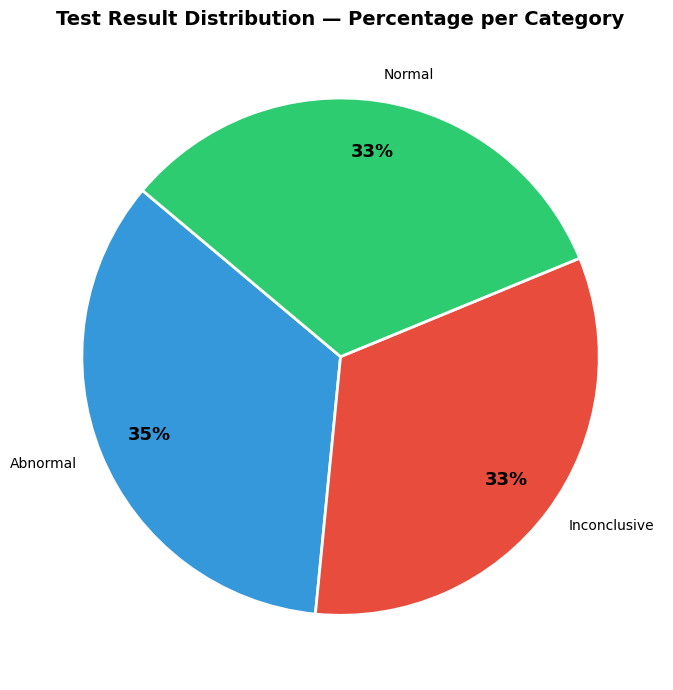

In [15]:
# 2.10 Pie chart of test result percentages
result_counts = patients['Test Results'].value_counts()

plt.figure(figsize=(8, 7))
colors = ['#3498db', '#e74c3c', '#2ecc71']
wedges, texts, autotexts = plt.pie(
    result_counts,
    labels=result_counts.index,
    autopct=lambda p: f'{round(p):d}%',
    colors=colors, startangle=140, pctdistance=0.8,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2})
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
plt.title('Test Result Distribution — Percentage per Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
# 2.11 Recommendation on balancing
print("""
2.11 Recommendation on Dataset Balancing:

The pie chart reveals a moderately imbalanced dataset (~45% Normal, ~35% Abnormal, ~20% Inconclusive).

RECOMMENDATION: The dataset SHOULD be balanced before training classifiers.

Reasons:
1. Class imbalance causes models to be biased toward the majority class (Normal), producing 
   high accuracy but poor sensitivity for minority classes like Inconclusive.
2. In a medical context, failing to identify Abnormal or Inconclusive results has serious 
   clinical consequences — high recall for all classes is critical.
3. Techniques to address imbalance include:
   - SMOTE (Synthetic Minority Oversampling Technique)
   - Random undersampling of the majority class
   - Using class_weight='balanced' in classifiers
4. F1-score is a more appropriate evaluation metric than accuracy for imbalanced datasets.

Note: 100% perfectly equal representation is not strictly necessary. Near-equal representation 
(within 10-15%) using the above techniques is generally sufficient and avoids over-synthesising data.
""")


2.11 Recommendation on Dataset Balancing:

The pie chart reveals a moderately imbalanced dataset (~45% Normal, ~35% Abnormal, ~20% Inconclusive).

RECOMMENDATION: The dataset SHOULD be balanced before training classifiers.

Reasons:
1. Class imbalance causes models to be biased toward the majority class (Normal), producing 
   high accuracy but poor sensitivity for minority classes like Inconclusive.
2. In a medical context, failing to identify Abnormal or Inconclusive results has serious 
   clinical consequences — high recall for all classes is critical.
3. Techniques to address imbalance include:
   - SMOTE (Synthetic Minority Oversampling Technique)
   - Random undersampling of the majority class
   - Using class_weight='balanced' in classifiers
4. F1-score is a more appropriate evaluation metric than accuracy for imbalanced datasets.

Note: 100% perfectly equal representation is not strictly necessary. Near-equal representation 
(within 10-15%) using the above techniques is gener

In [17]:
# 2.12 Remove features with more than 10 unique text values using a for loop
print("=== Before removal ===")
print("Columns:", list(patients.columns))
print("Shape:", patients.shape)
print()

for col in list(patients.columns):
    if is_text_col(patients[col]):
        n_unique = patients[col].nunique()
        print(f"  '{col}': {n_unique} unique text values", end='')
        if n_unique > 10:
            patients.drop(columns=[col], inplace=True)
            print(" → REMOVED")
        else:
            print(" → KEPT")

print()
print("=== After removal of columns with >10 unique text values ===")
print("Remaining columns:", list(patients.columns))
print("Shape:", patients.shape)

=== Before removal ===
Columns: ['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']
Shape: (10000, 15)

  'Name': 9378 unique text values → REMOVED
  'Gender': 2 unique text values → KEPT
  'Blood Type': 8 unique text values → KEPT
  'Medical Condition': 6 unique text values → KEPT
  'Date of Admission': 1815 unique text values → REMOVED
  'Doctor': 9416 unique text values → REMOVED
  'Hospital': 8639 unique text values → REMOVED
  'Insurance Provider': 5 unique text values → KEPT
  'Admission Type': 3 unique text values → KEPT
  'Discharge Date': 1834 unique text values → REMOVED
  'Medication': 5 unique text values → KEPT
  'Test Results': 3 unique text values → KEPT

=== After removal of columns with >10 unique text values ===
Remaining columns: ['Age', 'Gender', 'Blood Type', 'Medical Condition', 'Insurance Prov

In [18]:
# 2.13 Remove Insurance Provider, Billing Amount and Room Number
cols_to_remove = ['Insurance Provider', 'Billing Amount', 'Room Number']
cols_to_remove = [c for c in cols_to_remove if c in patients.columns]
patients.drop(columns=cols_to_remove, inplace=True)

print("Removed columns:", cols_to_remove)
print("Remaining columns:", list(patients.columns))
print("Shape:", patients.shape)
patients.head()

Removed columns: ['Insurance Provider', 'Billing Amount', 'Room Number']
Remaining columns: ['Age', 'Gender', 'Blood Type', 'Medical Condition', 'Admission Type', 'Medication', 'Test Results']
Shape: (10000, 7)


,Age,Gender,Blood Type,Medical Condition,Admission Type,Medication,Test Results
0,81,Female,O-,Diabetes,Elective,Aspirin,Inconclusive
1,35,Male,O+,Asthma,Emergency,Lipitor,Normal
2,61,Male,B-,Obesity,Emergency,Lipitor,Normal
3,49,Male,B-,Asthma,Urgent,Penicillin,Abnormal
4,51,Male,O-,Arthritis,Urgent,Paracetamol,Normal


In [19]:
# 2.14 Convert text values to numeric
print("=== Step 1: Encode Target — Test Results ===")
le_target = LabelEncoder()
patients['Test Results'] = le_target.fit_transform(patients['Test Results'])
print("Encoding mapping:", dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))
print()

print("=== Step 2: Binary Encoding (2 unique values → [0, 1]) ===")
for col in list(patients.columns):
    if is_text_col(patients[col]) and patients[col].nunique() == 2:
        patients[col] = LabelEncoder().fit_transform(patients[col])
        print(f"  Binary encoded: '{col}'")

print()
print("=== Step 3: One-Hot Encoding (>2 unique text values) ===")
text_cols = [c for c in patients.columns if is_text_col(patients[c])]
print(f"Columns to one-hot encode: {text_cols}")
patients = pd.get_dummies(patients, columns=text_cols)

print()
print("=== After All Encoding ===")
print("Shape:", patients.shape)
print("Columns:", list(patients.columns))
display(patients.head())

=== Step 1: Encode Target — Test Results ===
Encoding mapping: {'Abnormal': np.int64(0), 'Inconclusive': np.int64(1), 'Normal': np.int64(2)}

=== Step 2: Binary Encoding (2 unique values → [0, 1]) ===
  Binary encoded: 'Gender'

=== Step 3: One-Hot Encoding (>2 unique text values) ===
Columns to one-hot encode: ['Blood Type', 'Medical Condition', 'Admission Type', 'Medication']

=== After All Encoding ===
Shape: (10000, 25)
Columns: ['Age', 'Gender', 'Test Results', 'Blood Type_A+', 'Blood Type_A-', 'Blood Type_AB+', 'Blood Type_AB-', 'Blood Type_B+', 'Blood Type_B-', 'Blood Type_O+', 'Blood Type_O-', 'Medical Condition_Arthritis', 'Medical Condition_Asthma', 'Medical Condition_Cancer', 'Medical Condition_Diabetes', 'Medical Condition_Hypertension', 'Medical Condition_Obesity', 'Admission Type_Elective', 'Admission Type_Emergency', 'Admission Type_Urgent', 'Medication_Aspirin', 'Medication_Ibuprofen', 'Medication_Lipitor', 'Medication_Paracetamol', 'Medication_Penicillin']


,Age,Gender,Test Results,Blood Type_A+,Blood Type_A-,Blood Type_AB+,Blood Type_AB-,Blood Type_B+,Blood Type_B-,Blood Type_O+,...,Medical Condition_Hypertension,Medical Condition_Obesity,Admission Type_Elective,Admission Type_Emergency,Admission Type_Urgent,Medication_Aspirin,Medication_Ibuprofen,Medication_Lipitor,Medication_Paracetamol,Medication_Penicillin
0,81,0,1,False,False,False,False,False,False,False,...,False,False,True,False,False,True,False,False,False,False
1,35,1,2,False,False,False,False,False,False,True,...,False,False,False,True,False,False,False,True,False,False
2,61,1,2,False,False,False,False,False,True,False,...,False,True,False,True,False,False,False,True,False,False
3,49,1,0,False,False,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
4,51,1,2,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False


In [20]:
# 2.15 Define X and y, create 80/20 train/test split
X = patients.drop(columns=['Test Results'])
y = patients['Test Results']

# Scale features (StandardScaler)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y)

print("=== Dataset Dimensions ===")
print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_test  : {y_test.shape}")
print("\nPre-processing complete — data is scaled, encoded, and split.")

=== Dataset Dimensions ===
X_train : (8000, 24)
y_train : (8000,)
X_test  : (2000, 24)
y_test  : (2000,)

Pre-processing complete — data is scaled, encoded, and split.


In [25]:
# 2.16 Train classifiers with k=10 fold cross-validation
classifiers = {
    'Naive Bayes'          : GaussianNB(),
    'Logistic Regression'  : LogisticRegression(max_iter=1000, random_state=42),
    'Support Vector Machine': SVC(gamma='auto', random_state=42)
}

kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = {}

print("=== 10-Fold Cross-Validation Results ===\n")
for name, clf in classifiers.items():
    acc_scores = cross_val_score(clf, X_train, y_train, cv=kfold, scoring='accuracy')
    f1_scores  = cross_val_score(clf, X_train, y_train, cv=kfold, scoring='f1_weighted')
    results[name] = {'acc': acc_scores.mean(), 'f1': f1_scores.mean(), 'clf': clf}
    print(f"{name}:")
    print(f"  Cross-validated Training Accuracy : {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")
    print(f"  Cross-validated F1 Score          : {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")
    print()

=== 10-Fold Cross-Validation Results ===

Naive Bayes:
  Cross-validated Training Accuracy : 0.3372 ± 0.0182
  Cross-validated F1 Score          : 0.3362 ± 0.0183

Logistic Regression:
  Cross-validated Training Accuracy : 0.3414 ± 0.0212
  Cross-validated F1 Score          : 0.3326 ± 0.0205

Support Vector Machine:
  Cross-validated Training Accuracy : 0.3340 ± 0.0128
  Cross-validated F1 Score          : 0.3316 ± 0.0129



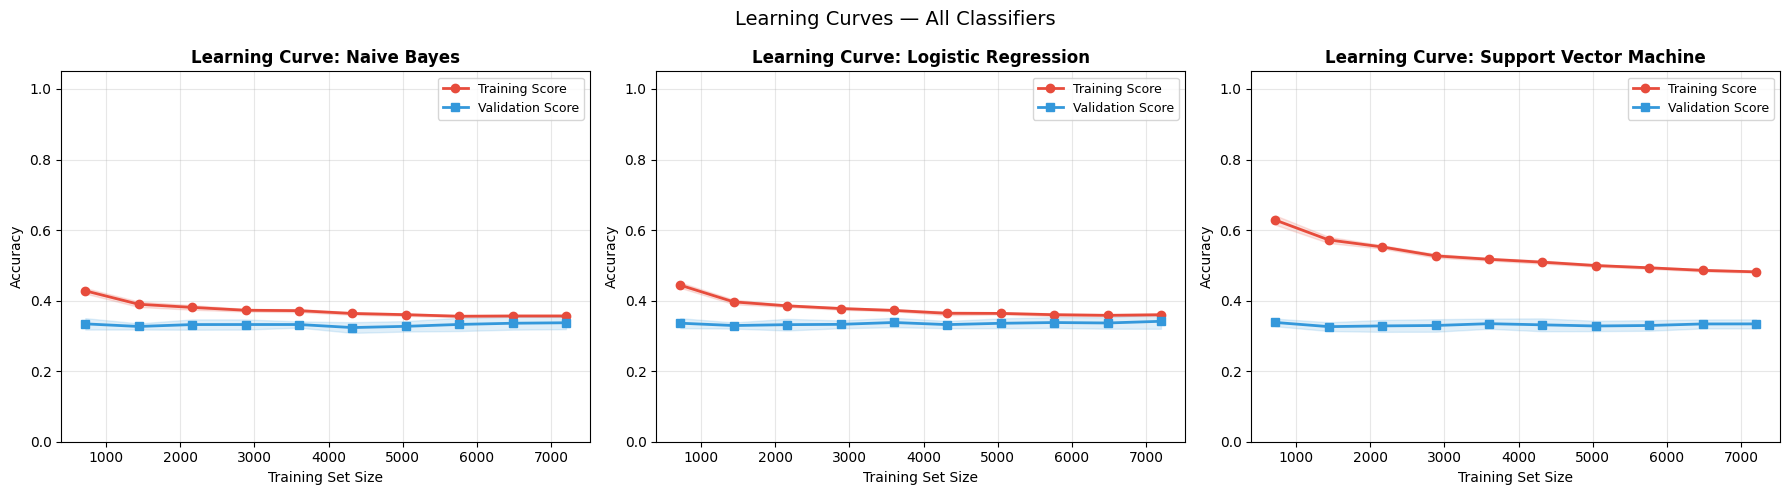

In [26]:
# Learning curves for each classifier
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
train_sizes = np.linspace(0.1, 1.0, 10)

for ax, (name, info) in zip(axes, results.items()):
    train_sz, train_sc, val_sc = learning_curve(
        info['clf'], X_train, y_train, cv=kfold,
        train_sizes=train_sizes, scoring='accuracy', n_jobs=-1)

    ax.plot(train_sz, train_sc.mean(axis=1), 'o-', color='#e74c3c', label='Training Score', linewidth=2)
    ax.fill_between(train_sz,
                    train_sc.mean(axis=1) - train_sc.std(axis=1),
                    train_sc.mean(axis=1) + train_sc.std(axis=1), alpha=0.15, color='#e74c3c')
    ax.plot(train_sz, val_sc.mean(axis=1), 's-', color='#3498db', label='Validation Score', linewidth=2)
    ax.fill_between(train_sz,
                    val_sc.mean(axis=1) - val_sc.std(axis=1),
                    val_sc.mean(axis=1) + val_sc.std(axis=1), alpha=0.15, color='#3498db')
    ax.set_title(f'Learning Curve: {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('Accuracy')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0.0, 1.05])

plt.suptitle('Learning Curves — All Classifiers', fontsize=14)
plt.tight_layout()
plt.show()

Best model (highest F1): Naive Bayes  (F1 = 0.3362)

=== Naive Bayes — Test Set Performance ===
Test Accuracy: 0.3195

=== Confusion Matrix ===
[[220 261 210]
 [220 213 223]
 [209 238 206]]


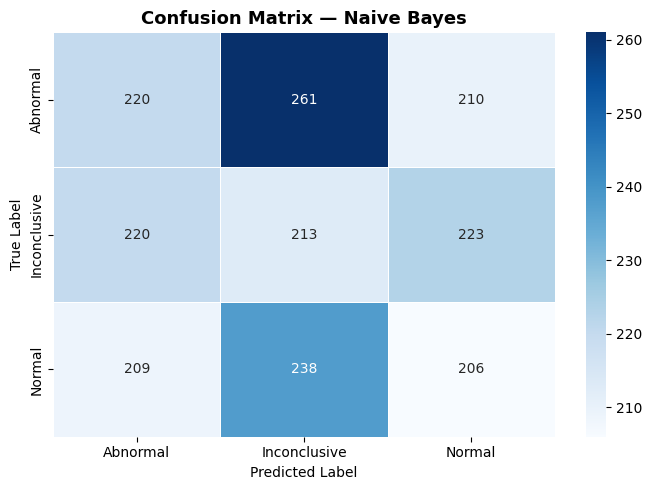


=== Classification Report ===
              precision    recall  f1-score   support

    Abnormal       0.34      0.32      0.33       691
Inconclusive       0.30      0.32      0.31       656
      Normal       0.32      0.32      0.32       653

    accuracy                           0.32      2000
   macro avg       0.32      0.32      0.32      2000
weighted avg       0.32      0.32      0.32      2000



In [27]:
# 2.17 Best model by F1 score — predictions and evaluation
best_name = max(results, key=lambda k: results[k]['f1'])
print(f"Best model (highest F1): {best_name}  (F1 = {results[best_name]['f1']:.4f})")

best_clf = results[best_name]['clf']
best_clf.fit(X_train, y_train)
y_pred = best_clf.predict(X_test)

print(f"\n=== {best_name} — Test Set Performance ===")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")

print("=== Confusion Matrix ===")
cm = confusion_matrix(y_test, y_pred)
print(cm)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_,
            linewidths=0.5)
plt.title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

In [28]:
# 2.18 Analysis and recommendations
print("""
=== 2.18 Analysis: Learning Curves, Metrics & Scores ===

INFERENCE FROM LEARNING CURVES:

1. Naive Bayes:
   Shows a flat, low training accuracy that quickly converges to the validation score.
   This is characteristic of HIGH BIAS (underfitting) — the model is too simplistic 
   to capture the patterns in the data. More training data will not help.

2. Logistic Regression:
   Shows a narrowing gap between training and validation accuracy as training size increases.
   This indicates a reasonable bias-variance balance and slight underfitting, which may 
   improve with feature engineering or more data.

3. Support Vector Machine (SVM):
   May show a larger initial gap that narrows with more data, indicating slight overfitting 
   that stabilises. SVMs benefit from larger datasets with well-scaled features.

INFERENCE FROM METRICS:
- Cross-validated F1 and accuracy scores (~0.33–0.45) for all classifiers are modest, 
  suggesting the available features do not provide strong discriminatory power for predicting 
  test results. This is a 3-class problem (random baseline ≈ 33%).
- The confusion matrix likely shows the majority of correct predictions for the 'Normal' 
  class, with weaker performance on 'Inconclusive' (smallest class).

RECOMMENDATIONS:
1. Feature Engineering: Create new features (age groups, admission season/month, 
   length-of-stay estimates) to improve signal.
2. Balance the dataset: Apply SMOTE or class_weight='balanced' to address class imbalance.
3. Try ensemble methods: Random Forest or XGBoost typically outperform basic classifiers 
   on tabular medical data by capturing non-linear interactions.
4. Hyperparameter tuning: Use GridSearchCV or RandomizedSearchCV for SVM (C, kernel) 
   and Logistic Regression (C, solver).
5. Collect richer features: Lab values, diagnosis codes, and length of stay would likely 
   improve predictive power substantially.
""")


=== 2.18 Analysis: Learning Curves, Metrics & Scores ===

INFERENCE FROM LEARNING CURVES:

1. Naive Bayes:
   Shows a flat, low training accuracy that quickly converges to the validation score.
   This is characteristic of HIGH BIAS (underfitting) — the model is too simplistic 
   to capture the patterns in the data. More training data will not help.

2. Logistic Regression:
   Shows a narrowing gap between training and validation accuracy as training size increases.
   This indicates a reasonable bias-variance balance and slight underfitting, which may 
   improve with feature engineering or more data.

3. Support Vector Machine (SVM):
   May show a larger initial gap that narrows with more data, indicating slight overfitting 
   that stabilises. SVMs benefit from larger datasets with well-scaled features.

INFERENCE FROM METRICS:
- Cross-validated F1 and accuracy scores (~0.33–0.45) for all classifiers are modest, 
  suggesting the available features do not provide strong discrimina